# Notebook 03 — Word Embeddings (Section 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import gensim
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import tensorboard
from torch.utils.tensorboard import SummaryWriter
import torch

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

DATA_PATH = Path("outputs/reviews_clean.csv")
OUTPUTS_DIR = Path("outputs")
MODELS_DIR = Path("models")
LOGS_DIR = Path("logs")
LOGS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Tokenize

In [2]:
df = pd.read_csv(DATA_PATH)
texts = df['text'].dropna().tolist()
print(f"Loaded {len(texts)} reviews")

STOP = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(str(text).lower())
    return [t for t in tokens if t.isalpha() and len(t) > 1]

print("Tokenizing...")
tokenized = [tokenize(t) for t in tqdm(texts)]
print(f"Done. Vocab preview: {tokenized[0][:8]}")

Loaded 24103 reviews
Tokenizing...


100%|██████████| 24103/24103 [00:03<00:00, 7400.74it/s]

Done. Vocab preview: ['best', 'insurance', 'price', 'solutions', 'listening', 'speed', 'and', 'recommend']


## 2. Train Word2Vec

In [3]:
print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    sg=1  # Skip-gram
)
w2v_model.save(str(MODELS_DIR / 'word2vec.model'))
print(f"Word2Vec trained. Vocab size: {len(w2v_model.wv)}")

# Test
print("\nWords similar to 'claim':")
print(w2v_model.wv.most_similar('claim', topn=5))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training Word2Vec...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec trained. Vocab size: 6334

Words similar to 'claim':
[('disaster', 0.8195363283157349), ('sinister', 0.7364623546600342), ('incident', 0.702651858329773), ('claims', 0.6863077878952026), ('glitch', 0.656545877456665)]


## 3. Load Pre-trained GloVe (glove.6B.100d)

In [4]:
import os

GLOVE_PATH = Path("outputs/glove.6B.100d.txt")

if not GLOVE_PATH.exists():
    print("GloVe file not found. Downloading...")
    import urllib.request
    import zipfile
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = Path("outputs/glove.6B.zip")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.100d.txt', 'outputs/')
    print("Downloaded.")
else:
    print("GloVe file found.")

# Load GloVe vectors
glove_vectors = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Loading GloVe"):
        parts = line.split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f"Loaded {len(glove_vectors)} GloVe vectors")

GloVe file not found. Downloading...
Downloaded.


Loading GloVe: 400000it [00:03, 104189.30it/s]

Loaded 400000 GloVe vectors


## 4. t-SNE Visualization of Top-200 Words

Running t-SNE...


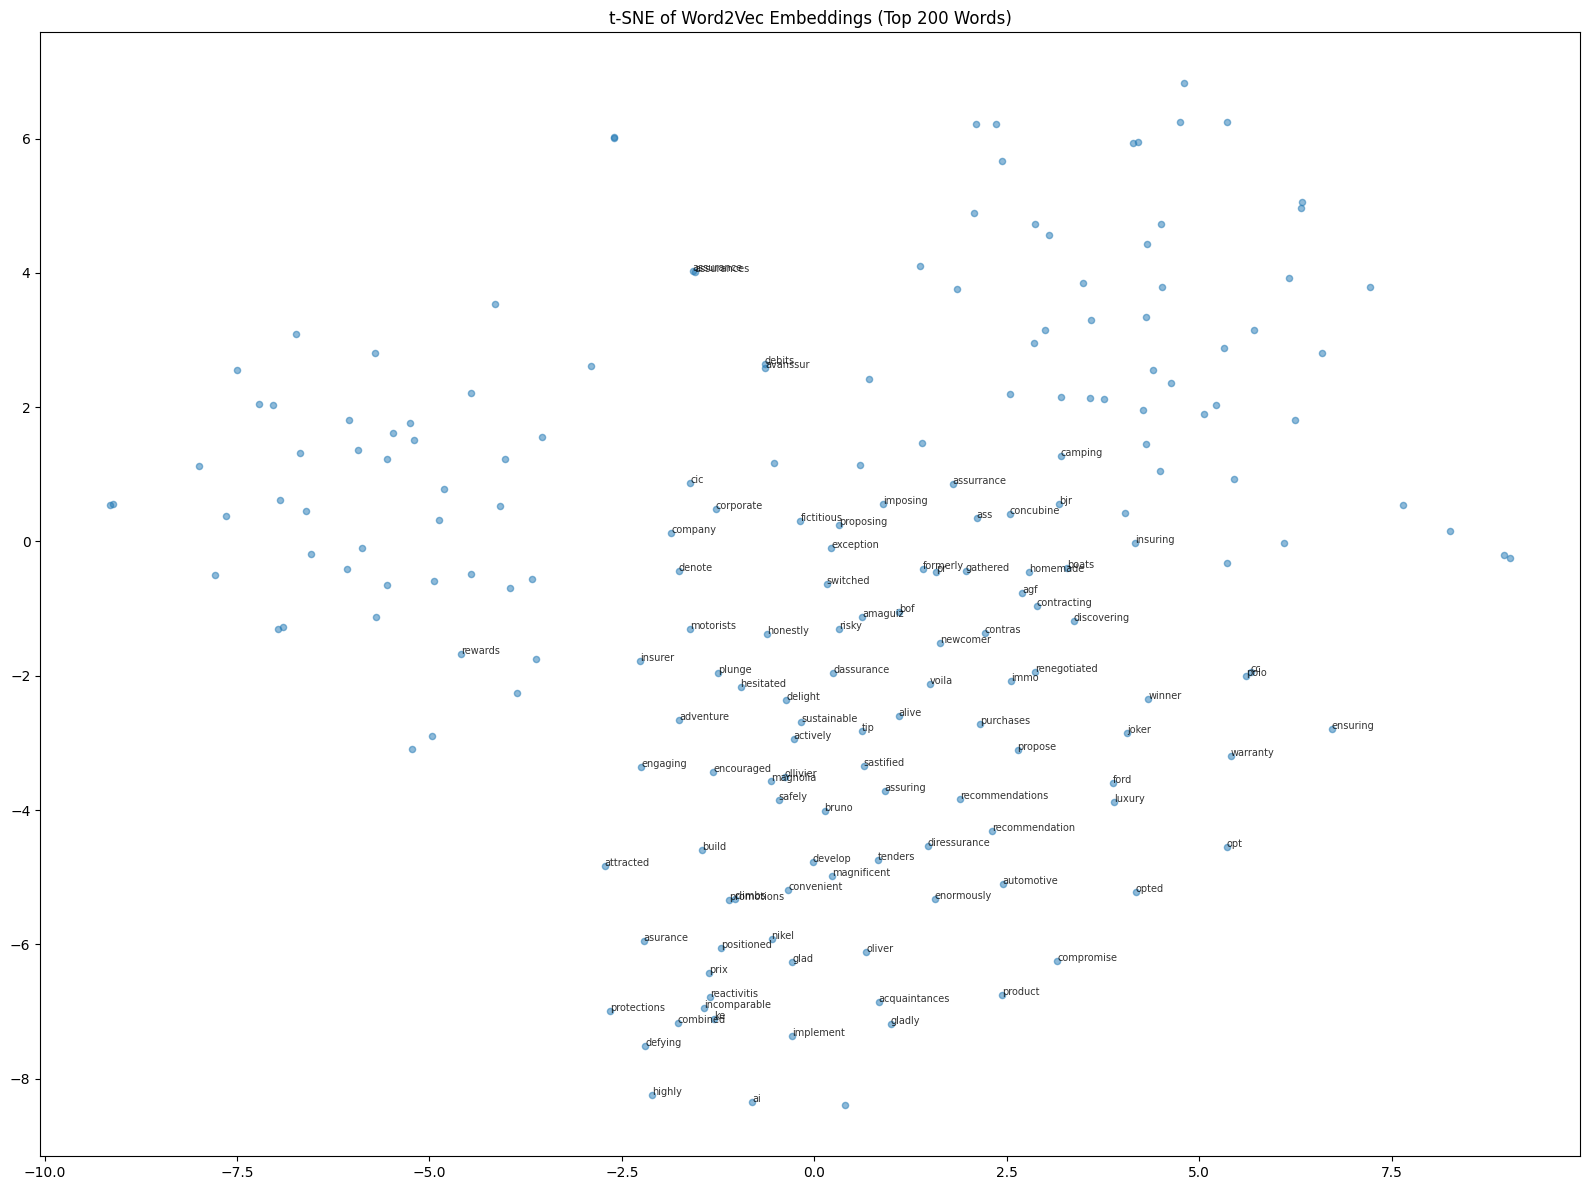

Saved tsne_embeddings.png


In [6]:
# Get top-200 words from Word2Vec vocabulary
top_words = [w for w, _ in w2v_model.wv.most_similar(positive=['insurance'], topn=100)]
top_words += [w for w, _ in w2v_model.wv.most_similar(positive=['claim'], topn=50)]
top_words += [w for w, _ in w2v_model.wv.most_similar(positive=['policy'], topn=50)]
top_words = list(dict.fromkeys(top_words))[:200]

vectors = np.array([w2v_model.wv[w] for w in top_words])

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(16, 12))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5, s=20)
for i, word in enumerate(top_words[:100]):  # label first 100
    plt.annotate(word, coords[i], fontsize=7, alpha=0.8)
plt.title('t-SNE of Word2Vec Embeddings (Top 200 Words)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'tsne_embeddings.png', dpi=100)
plt.show()
print("Saved tsne_embeddings.png")

## 5. TensorBoard Embedding Export

In [7]:
# Export embeddings to TensorBoard Projector
writer = SummaryWriter(log_dir=str(LOGS_DIR / 'embeddings'))

# Use top 500 words
top500 = list(w2v_model.wv.key_to_index.keys())[:500]
embed_matrix = torch.tensor(np.array([w2v_model.wv[w] for w in top500]))

writer.add_embedding(embed_matrix, metadata=top500, tag='word2vec')
writer.close()
print("TensorBoard embeddings exported to logs/embeddings/")
print("Run: tensorboard --logdir=logs/embeddings")

TensorBoard embeddings exported to logs/embeddings/
Run: tensorboard --logdir=logs/embeddings


## 6. Euclidean & Cosine Distance

In [8]:
from scipy.spatial.distance import euclidean, cosine

# Word pairs to compare
word_pairs = [
    ('claim', 'insurance'),
    ('price', 'cost'),
    ('service', 'support'),
    ('cancel', 'cancellation'),
    ('policy', 'coverage'),
    ('car', 'vehicle'),
    ('happy', 'satisfied'),
    ('bad', 'terrible'),
]

print(f"{'Word 1':<15} {'Word 2':<15} {'Euclidean':>12} {'Cosine Sim':>12}")
print("-" * 55)
for w1, w2 in word_pairs:
    if w1 in w2v_model.wv and w2 in w2v_model.wv:
        v1 = w2v_model.wv[w1]
        v2 = w2v_model.wv[w2]
        euc = euclidean(v1, v2)
        cos_sim = 1 - cosine(v1, v2)
        print(f"{w1:<15} {w2:<15} {euc:>12.4f} {cos_sim:>12.4f}")

Word 1          Word 2             Euclidean   Cosine Sim
-------------------------------------------------------
claim           insurance             3.0585       0.2939
price           cost                  3.1913       0.4367
service         support               3.1024       0.3983
cancel          cancellation          2.8657       0.4945
policy          coverage              3.6183       0.2663
car             vehicle               1.5222       0.8606
happy           satisfied             2.1158       0.8231
bad             terrible              2.8121       0.4391


## 7. Semantic Search with Sentence-Transformers + FAISS (Bonus)

In [9]:
from sentence_transformers import SentenceTransformer
import faiss

print("Loading sentence transformer...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode a sample of reviews
sample_texts = texts[:2000]
print(f"Encoding {len(sample_texts)} reviews...")
embeddings = st_model.encode(sample_texts, batch_size=64, show_progress_bar=True)
embeddings = embeddings.astype(np.float32)

# Build FAISS index
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)
print(f"FAISS index built with {index.ntotal} vectors")

# Save
np.save(OUTPUTS_DIR / 'sentence_embeddings.npy', embeddings)
faiss.write_index(index, str(OUTPUTS_DIR / 'faiss_index.bin'))
print("Saved sentence_embeddings.npy and faiss_index.bin")

Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 2000 reviews...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

FAISS index built with 2000 vectors
Saved sentence_embeddings.npy and faiss_index.bin


In [10]:
def semantic_search(query, k=5):
    q_emb = st_model.encode([query]).astype(np.float32)
    distances, indices = index.search(q_emb, k)
    print(f"\nQuery: '{query}'")
    print(f"{'#':<5} {'Distance':>10} Review")
    print("-" * 80)
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        print(f"{rank+1:<5} {dist:>10.4f} {sample_texts[idx][:80]}")

semantic_search("bad claims experience")
semantic_search("excellent customer service")
semantic_search("too expensive premium")


Query: 'bad claims experience'
#       Distance Review
--------------------------------------------------------------------------------
1         0.8222 After 2 claims at 7 days apart (1st sinister a car vandalism completely striped 
2         0.8721 member for many years 3 claims not responsible for many years and we are termina
3         0.9114 After 2 small claims the maff wants to harm my account.
I have been at home for 
4         0.9178 Very bad on the side of loss and compensation management! To exclude! Claim decl
5         0.9200 After a sinister which took 6 months to be ruled I expressed a mood ticket to th

Query: 'excellent customer service'
#       Distance Review
--------------------------------------------------------------------------------
1         0.7037 Very good serious customer relationship service fast reimbursements
2         0.7291 I am satisfied with the service to offer fast reliable cheap
Very fast as a serv
3         0.7439 I am satisfied with customer se

## Summary
- Trained Word2Vec (skip-gram, 100d) on all reviews
- Loaded pre-trained GloVe 100d
- t-SNE visualization of top-200 words
- TensorBoard embedding export
- Euclidean + cosine distance table
- Semantic search with sentence-transformers + FAISS (bonus)